<a href="https://colab.research.google.com/github/kunal13-Ai/Practice_of_ML/blob/main/AUS_weather_Trainig_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/weatherAUS.csv.zip')

In [ ]:
df.sample(6)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
121647,2011-05-06,Perth,12.3,23.0,0.0,4.2,10.0,SSW,26.0,SE,...,53.0,35.0,1022.9,1019.6,1.0,1.0,16.6,22.5,No,No
137727,2013-09-11,AliceSprings,10.9,34.2,0.0,8.4,8.2,NE,43.0,ESE,...,29.0,12.0,1015.1,1010.3,6.0,6.0,20.6,33.3,No,No
81029,2009-02-01,Dartmoor,NaN,NaN,NaN,6.4,10.6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49568,2010-05-30,Tuggeranong,8.2,13.7,17.8,NaN,NaN,SSE,65.0,NW,...,99.0,100.0,1003.2,1001.1,NaN,NaN,9.0,10.2,Yes,NaN
10968,2014-06-23,CoffsHarbour,7.1,21.0,0.0,NaN,NaN,NaN,NaN,NaN,...,73.0,53.0,NaN,NaN,NaN,NaN,15.7,20.4,No,No
84536,2009-12-12,Brisbane,23.6,30.8,0.0,8.0,7.2,E,31.0,SSE,...,62.0,53.0,1015.9,1012.2,7.0,7.0,27.7,29.8,No,No


In [3]:
df.shape

(145460, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df_infer = df[df['RainTomorrow'].isna()].copy()

In [7]:
df.dropna(subset='RainTomorrow',inplace= True)

In [8]:
df.shape

(142193, 23)

In [10]:
df_col = df.columns
df_col

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [11]:
df.dtypes.value_counts()

,count
float64,16
object,7


# Handling missing values


In [12]:
num_cols =  df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [13]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols.tolist()

['Date',
 'Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

In [14]:
for col in cat_cols:
    df[col] = df[col].fillna(df.groupby('Location')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'))

In [15]:
for col in num_cols:

  df[col] = df[col].fillna(df.groupby('Location')[col].transform('median'))
  df[col] = df[col].fillna(df[col].median())

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   Evaporation    142193 non-null  float64
 6   Sunshine       142193 non-null  float64
 7   WindGustDir    142193 non-null  object 
 8   WindGustSpeed  142193 non-null  float64
 9   WindDir9am     142193 non-null  object 
 10  WindDir3pm     142193 non-null  object 
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  Humidity9am    142193 non-null  float64
 14  Humidity3pm    142193 non-null  float64
 15  Pressure9am    142193 non-null  float64
 16  Pressure3pm    142193 non-null  float64
 17  Cloud9am       142193 non-null  fl

In [17]:
df.isnull().sum().sum()

np.int64(0)

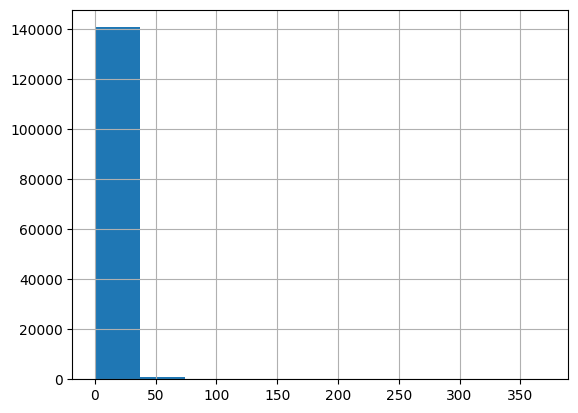

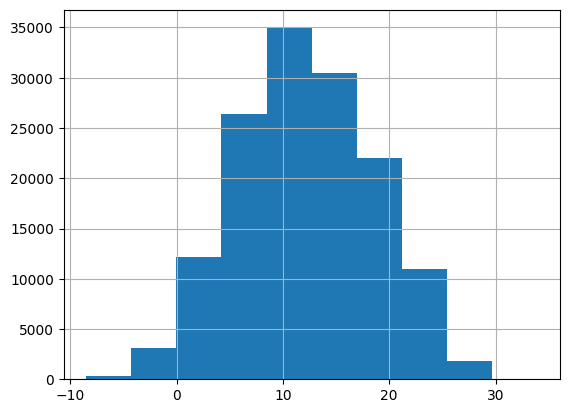

In [ ]:
df['Rainfall'].hist()
plt.show() ,

df['MinTemp'].hist()
plt.show()

(<Axes: xlabel='MinTemp', ylabel='Density'>,)

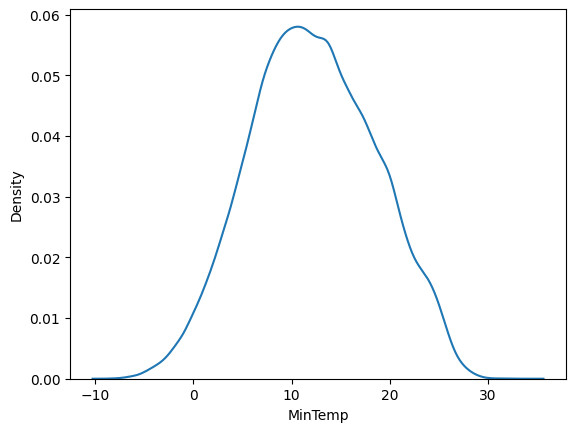

In [ ]:
sns.kdeplot(df['MinTemp']),
#sns.kdeplot(df['MaxTemp'])

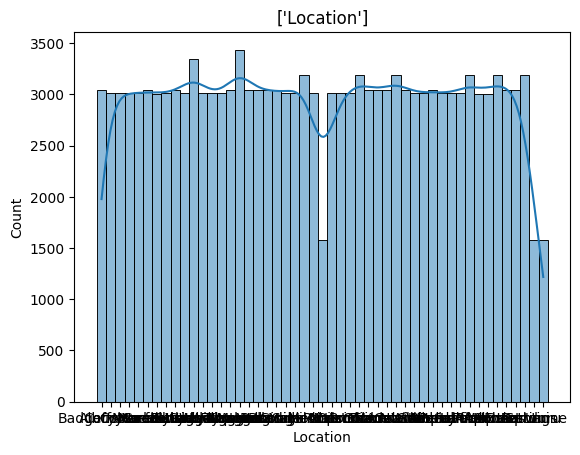

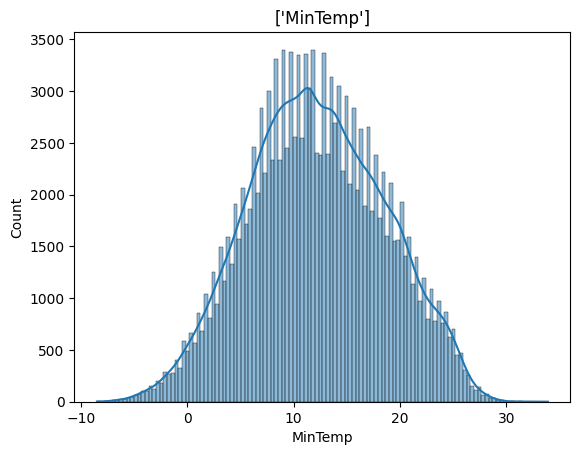

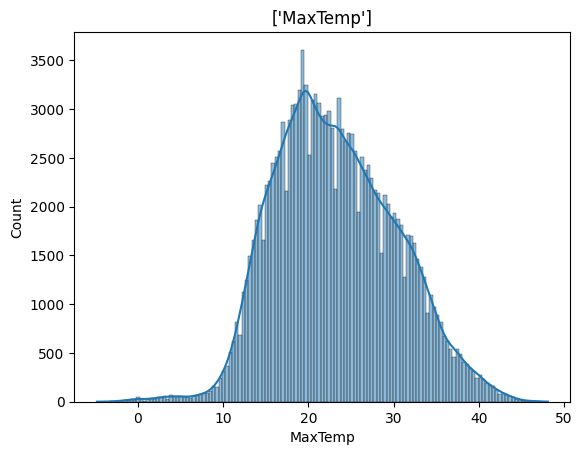

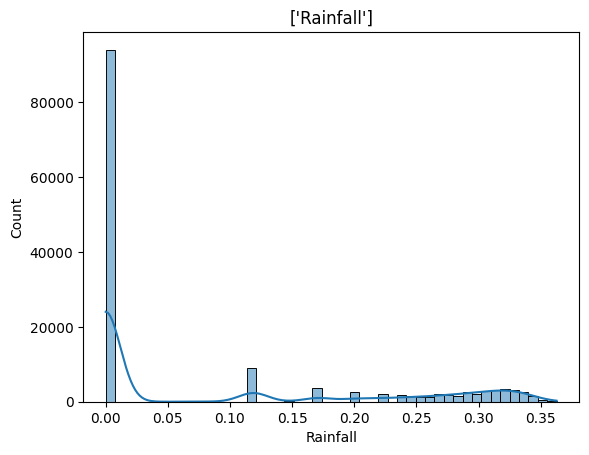

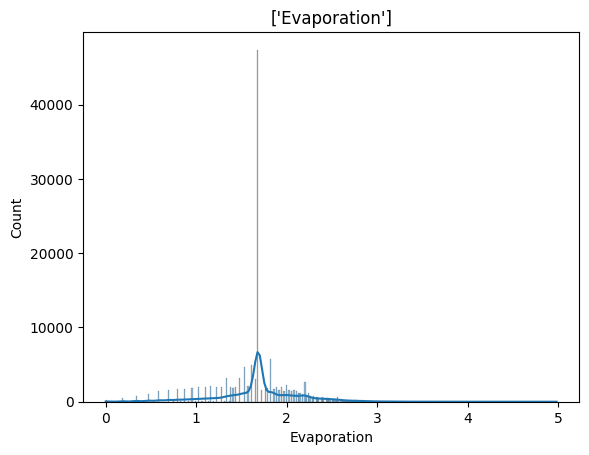

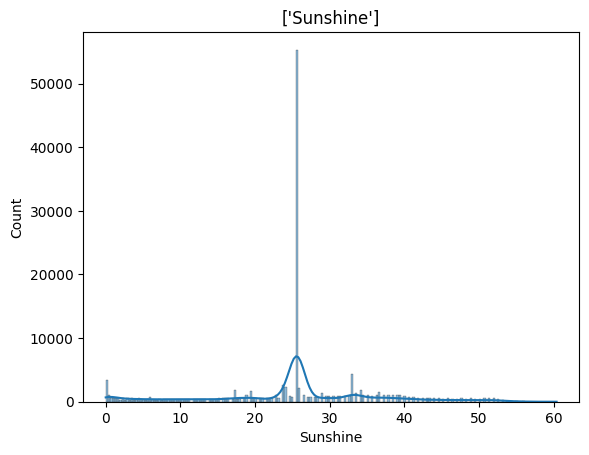

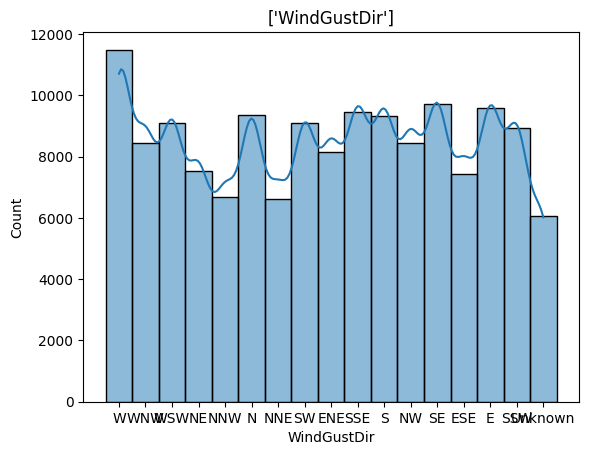

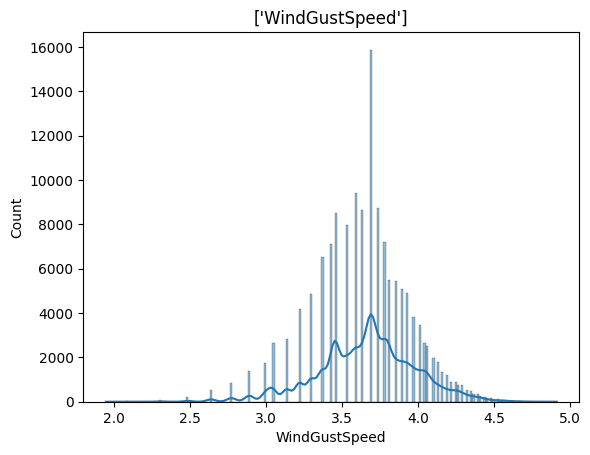

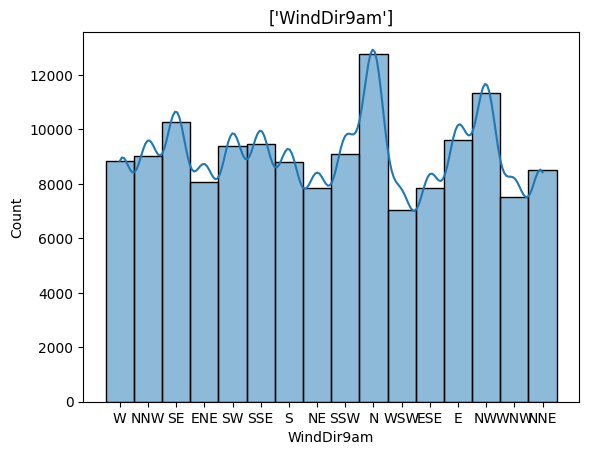

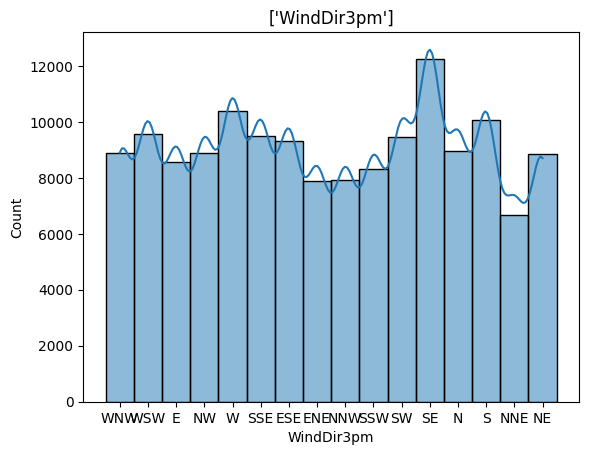

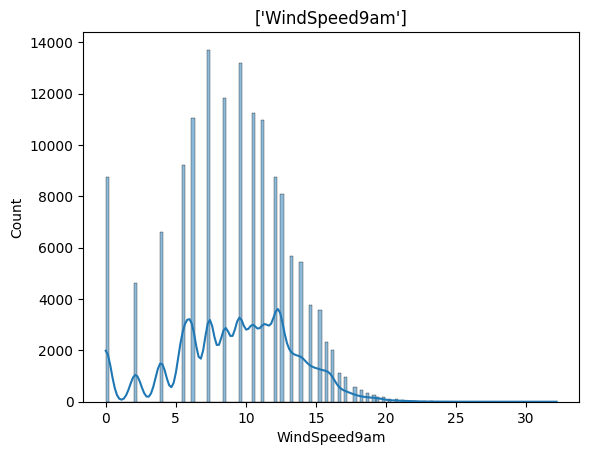

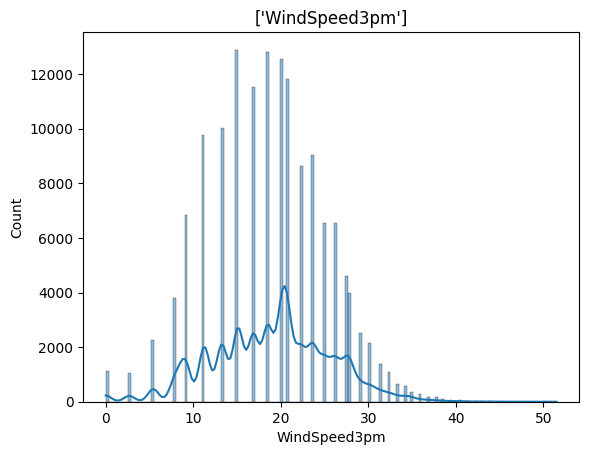

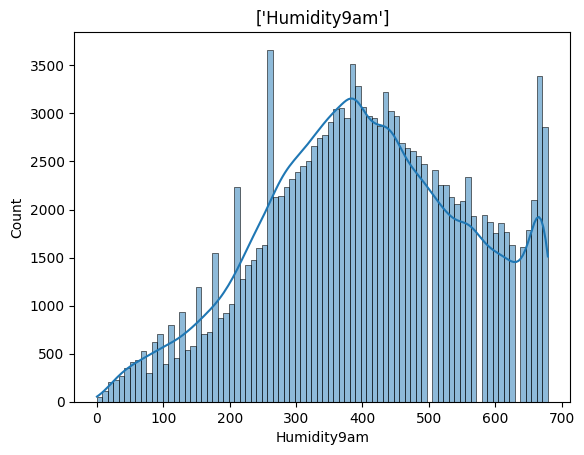

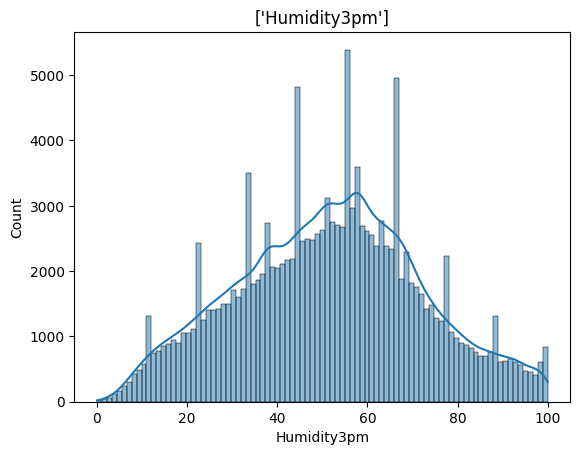

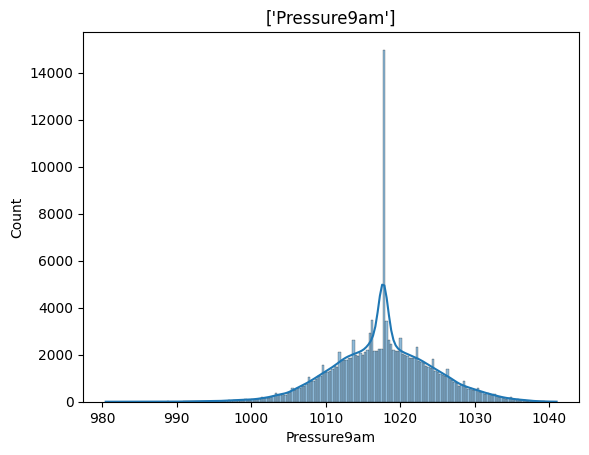

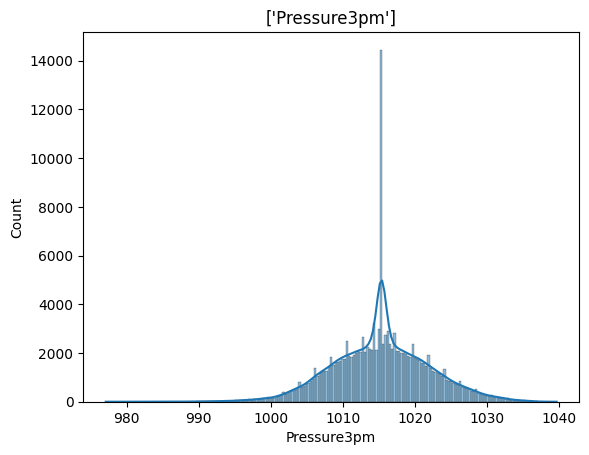

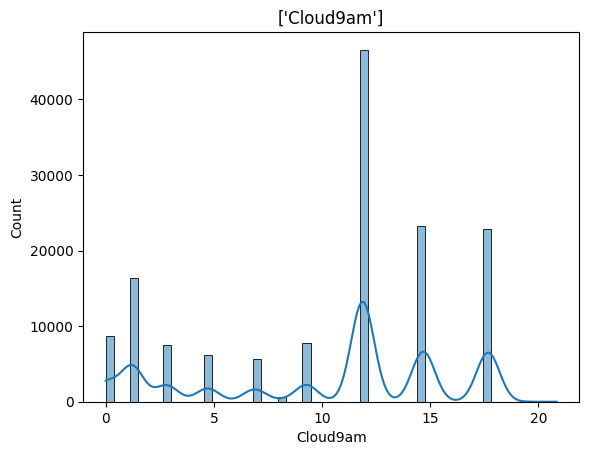

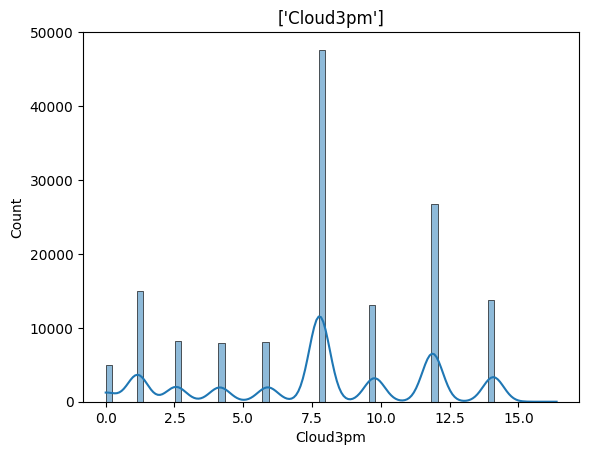

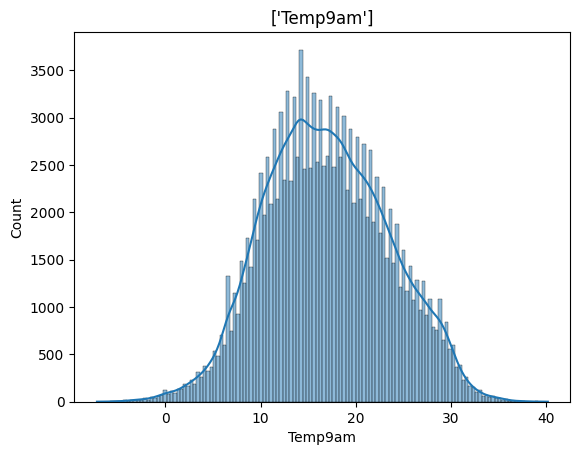

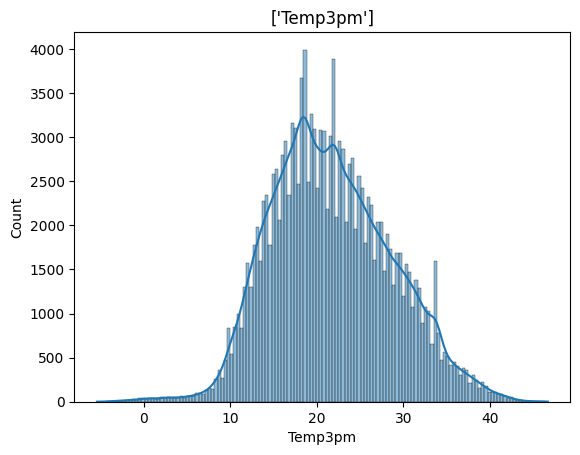

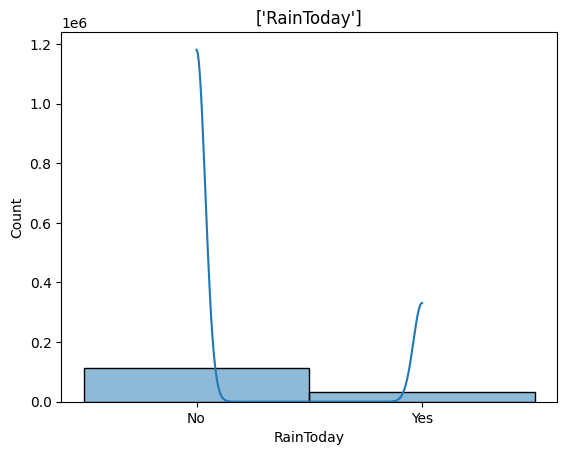

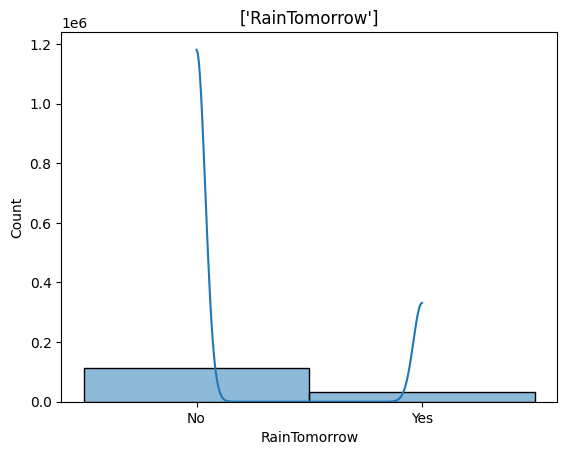

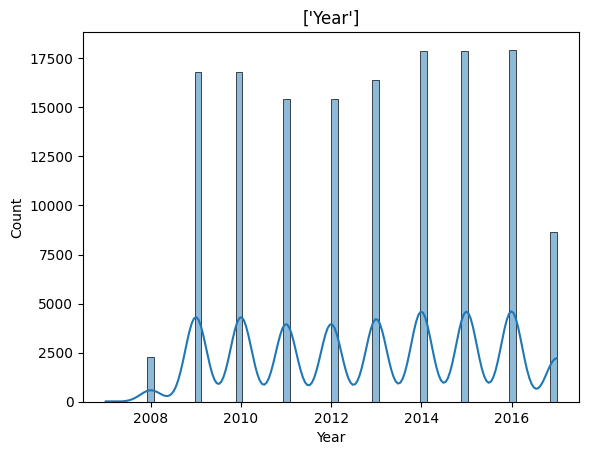

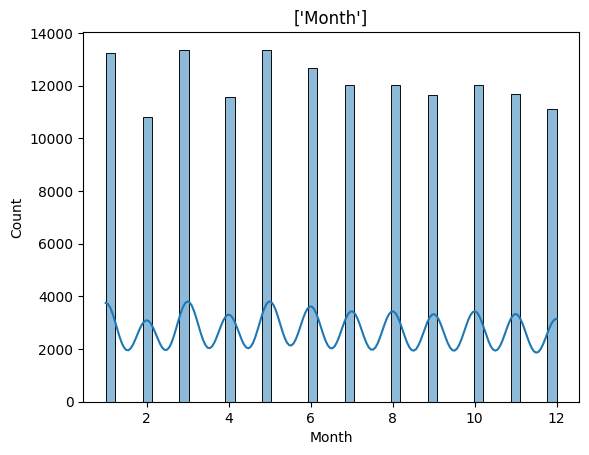

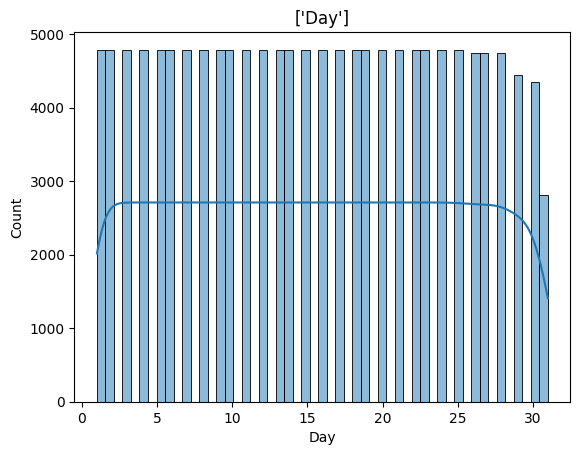

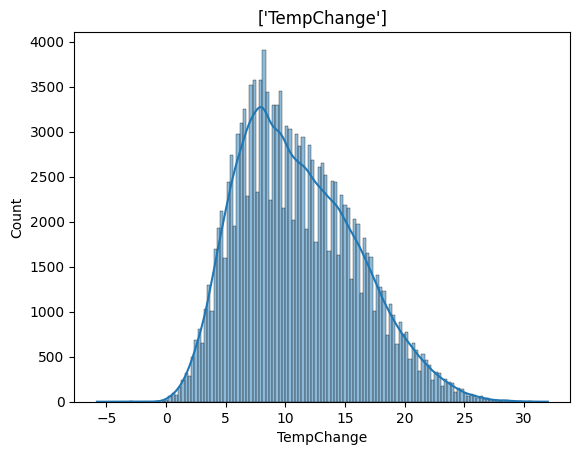

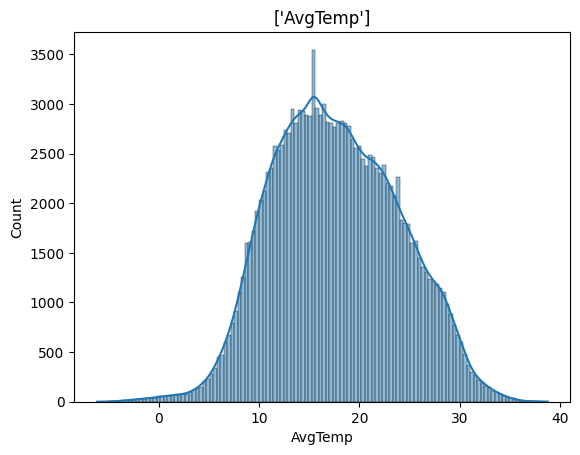

In [ ]:
from matplotlib import figure
for col in df:
  sns.histplot(df[col],kde=True)
  plt.title([col])
  plt.show()

# Checking skewnees

In [18]:
df['RainTomorrow'] = df['RainTomorrow'].map({'No':0, 'Yes':1})
df['RainToday'] = df['RainToday'].map({ 'No':0, 'Yes':1})

In [19]:
skewness=df.skew(numeric_only=True)
print(skewness)

MinTemp          0.022802
MaxTemp          0.225167
Rainfall         9.934102
Evaporation      5.023624
Sunshine        -1.040572
WindGustSpeed    0.912883
WindSpeed9am     0.780321
WindSpeed3pm     0.638003
Humidity9am     -0.491853
Humidity3pm      0.025111
Pressure9am     -0.097400
Pressure3pm     -0.045486
Cloud9am        -0.748178
Cloud3pm        -0.554813
Temp9am          0.092786
Temp3pm          0.241817
RainToday        1.343357
RainTomorrow     1.322753
dtype: float64


In [20]:
from scipy.stats import boxcox


df["Sunshine"], _ = boxcox(df["Sunshine"] + 1)
df["Cloud9am"], _ = boxcox(df["Cloud9am"] + 1)
df["Cloud3pm"], _ = boxcox(df["Cloud3pm"] + 1)
df["Humidity9am"], _ = boxcox(df["Humidity9am"] + 1)


In [21]:
df[["Sunshine","Cloud9am","Cloud3pm","Humidity9am"]].skew()

,0
Sunshine,-0.168775
Cloud9am,-0.494187
Cloud3pm,-0.292748
Humidity9am,-0.115170


In [22]:
df['Evaporation'] = np.log1p(df['Evaporation'])
df['WindGustSpeed'] = np.log1p(df['WindGustSpeed'])



In [23]:
df["WindSpeed9am"], _ = boxcox(df["WindSpeed9am"] + 1)
df["WindSpeed3pm"], _ = boxcox(df["WindSpeed3pm"] + 1)


In [30]:
df['Rainfall'] = np.sqrt(df['Rainfall'])

In [31]:
print(df.skew(numeric_only=True))

MinTemp          0.022802
MaxTemp          0.225167
Rainfall         0.796804
Evaporation     -0.184396
Sunshine        -0.168775
WindGustSpeed   -0.285239
WindSpeed9am    -0.057247
WindSpeed3pm     0.016631
Humidity9am     -0.115170
Humidity3pm      0.025111
Pressure9am     -0.097400
Pressure3pm     -0.045486
Cloud9am        -0.494187
Cloud3pm        -0.292748
Temp9am          0.092786
Temp3pm          0.241817
RainToday        1.343357
RainTomorrow     1.322753
dtype: float64


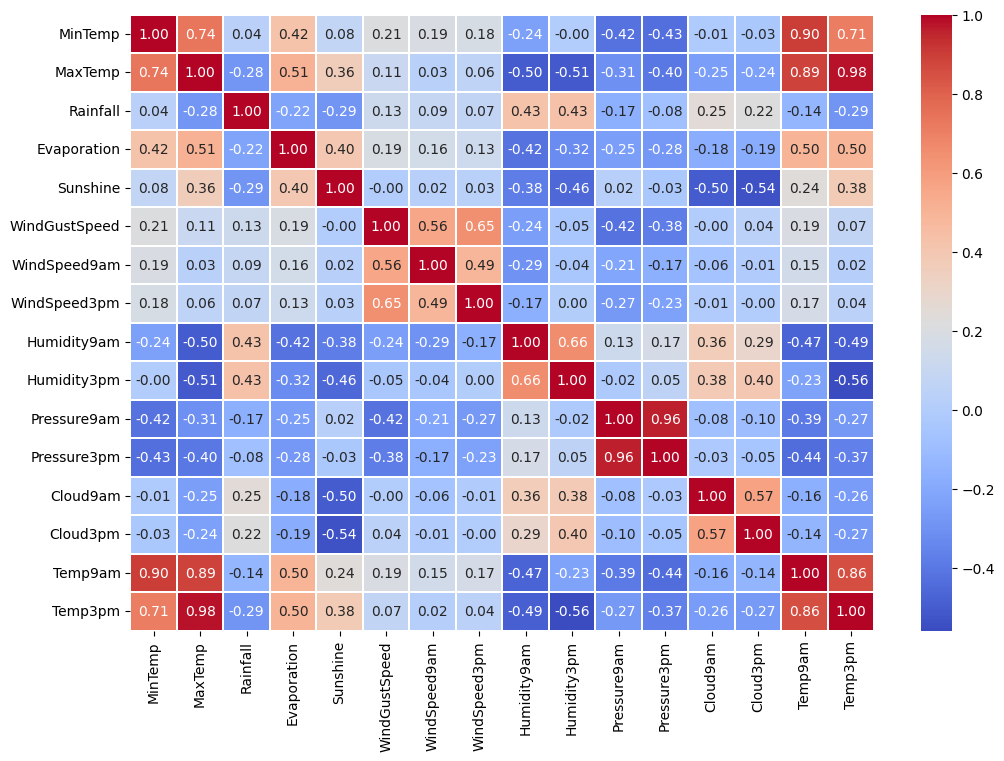

In [ ]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.2)
plt.show('corration between variables')

## Feature enggineering

In [32]:
df['Date'] = pd.to_datetime(df['Date'])

In [33]:
df['Month'] = df['Date'].dt.month
df['Month'].head()

,Month
0,12
1,12
2,12
3,12
4,12


In [34]:
df.drop(columns=['Date'],inplace=True)

In [ ]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,2008-12-01,Albury,13.4,22.9,0.827990,1.686399,25.493352,W,3.806662,W,...,22.0,1007.7,1007.1,17.118136,11.679925,16.9,21.8,No,No,12
1,2008-12-02,Albury,7.4,25.1,0.000000,1.686399,25.493352,WNW,3.806662,NNW,...,25.0,1010.6,1007.8,17.118136,11.679925,17.2,24.3,No,No,12
2,2008-12-03,Albury,12.9,25.7,0.000000,1.686399,25.493352,WSW,3.850148,W,...,30.0,1007.6,1008.7,17.118136,2.538686,21.0,23.2,No,No,12
3,2008-12-04,Albury,9.2,28.0,0.000000,1.686399,25.493352,NE,3.218876,SE,...,16.0,1017.6,1012.8,17.118136,11.679925,18.1,26.5,No,No,12
4,2008-12-05,Albury,17.5,32.3,0.912444,1.686399,25.493352,W,3.737670,ENE,...,33.0,1010.8,1006.0,14.250968,13.834886,17.8,29.7,No,No,12


In [35]:
# to see range of temp in day
df['TempRange'] = df['MaxTemp'] - df['MinTemp']

In [36]:
# to see avg temp in day
df['AvgTemp'] = (df['MinTemp']+df['MaxTemp']) / 2

In [37]:
df['TempChange'] = df['Temp3pm'] - df['Temp9am']

In [38]:
df['PressureChange'] = df['Pressure3pm'] - df['Pressure9am']

In [39]:
df["HumidityChange"] = df["Humidity3pm"] - df["Humidity9am"]

In [40]:
df["WindSpeedChange"] = df["WindSpeed3pm"] - df["WindSpeed9am"]

In [41]:
df['AvgCloud'] = (df['Cloud3pm'] + df['Cloud9am']) / 2

In [42]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,RainToday,RainTomorrow,Month,TempRange,AvgTemp,TempChange,PressureChange,HumidityChange,WindSpeedChange,AvgCloud
0,Albury,13.4,22.9,0.938143,1.686399,25.493352,W,3.806662,W,WNW,...,0,0,12,9.5,18.15,4.9,-0.6,-378.424625,1.466847,14.399031
1,Albury,7.4,25.1,0.000000,1.686399,25.493352,WNW,3.806662,NNW,WSW,...,0,0,12,17.7,16.25,7.1,-2.8,-172.910257,6.566159,14.399031
2,Albury,12.9,25.7,0.000000,1.686399,25.493352,WSW,3.850148,W,WSW,...,0,0,12,12.8,19.30,2.2,1.1,-129.646831,2.284369,9.828411
3,Albury,9.2,28.0,0.000000,1.686399,25.493352,NE,3.218876,SE,E,...,0,0,12,18.8,18.60,8.4,-4.8,-188.547018,-0.587890,14.399031
4,Albury,17.5,32.3,1.000000,1.686399,25.493352,W,3.737670,ENE,NW,...,0,0,12,14.8,24.90,11.9,-4.8,-462.467996,4.623035,14.042927


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Location         142193 non-null  object 
 1   MinTemp          142193 non-null  float64
 2   MaxTemp          142193 non-null  float64
 3   Rainfall         142193 non-null  float64
 4   Evaporation      142193 non-null  float64
 5   Sunshine         142193 non-null  float64
 6   WindGustDir      142193 non-null  object 
 7   WindGustSpeed    142193 non-null  float64
 8   WindDir9am       142193 non-null  object 
 9   WindDir3pm       142193 non-null  object 
 10  WindSpeed9am     142193 non-null  float64
 11  WindSpeed3pm     142193 non-null  float64
 12  Humidity9am      142193 non-null  float64
 13  Humidity3pm      142193 non-null  float64
 14  Pressure9am      142193 non-null  float64
 15  Pressure3pm      142193 non-null  float64
 16  Cloud9am         142193 non-null  float64
 

# Encoding category to numeric


In [44]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder


In [45]:
df.shape

(142193, 30)

In [82]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_cat = encoder.fit_transform(df[['Location','WindGustDir','WindDir9am','WindDir3pm']])

In [118]:
encoded_cols = encoder.get_feature_names_out()
df_encoded = pd.DataFrame(X_cat, columns=encoded_cols)

In [84]:
df_encoded.shape

(142193, 94)

In [ ]:
df_encoded.head(1)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.938143,1.686399,25.493352,3.806662,8.309537,9.776384,400.424625,22.0,...,False,False,False,False,False,False,False,False,True,False


# Detecting outliears

In [50]:
df['Month']=df['Month'].astype(np.float64)
(df['Month'].dtype)

dtype('float64')

In [51]:
num_cols = df.select_dtypes(include=['float64']).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'Month', 'TempRange', 'AvgTemp', 'TempChange',
       'PressureChange', 'HumidityChange', 'WindSpeedChange', 'AvgCloud'],
      dtype='object')

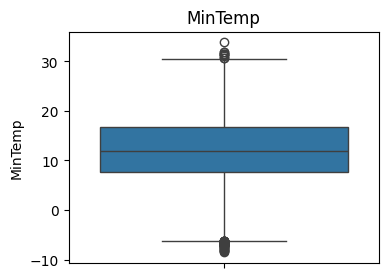

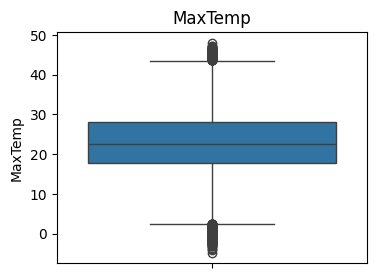

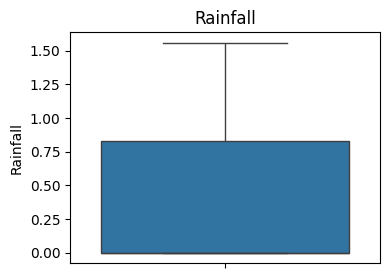

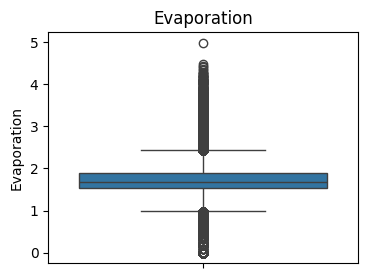

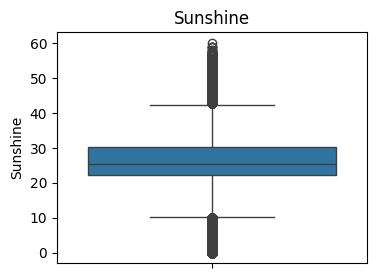

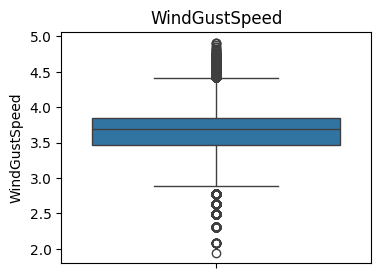

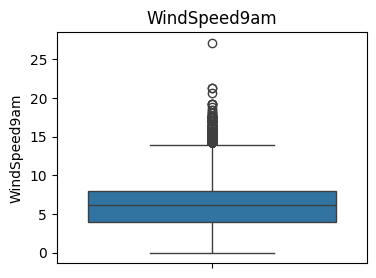

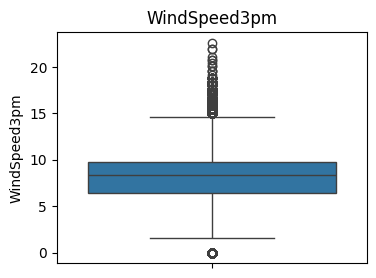

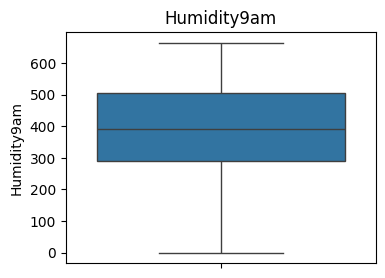

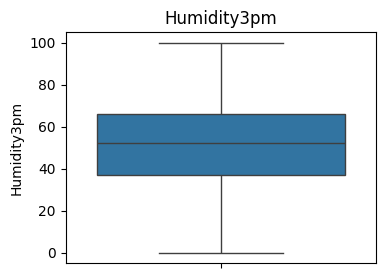

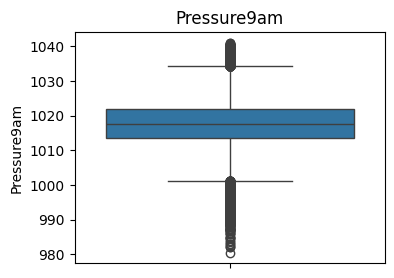

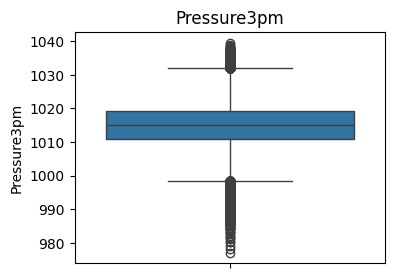

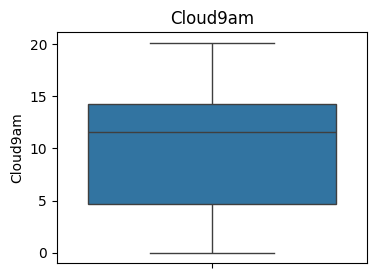

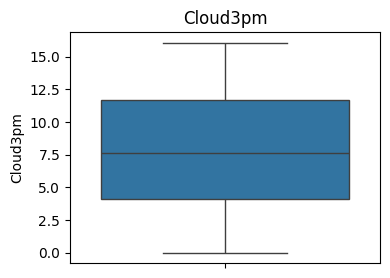

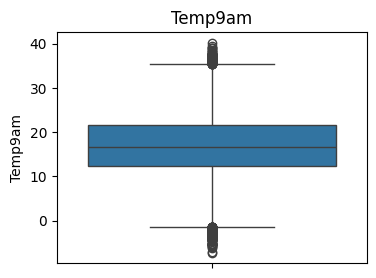

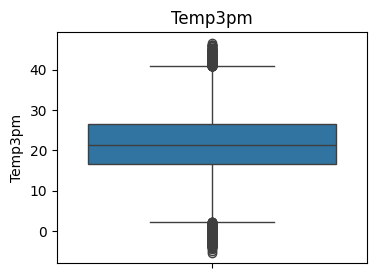

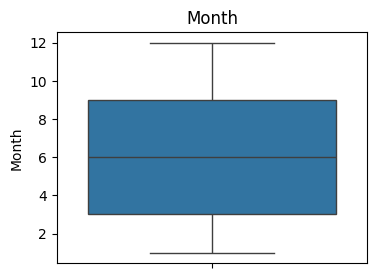

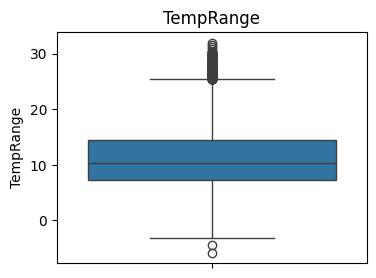

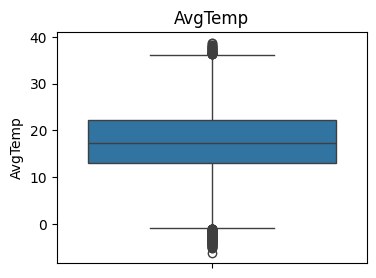

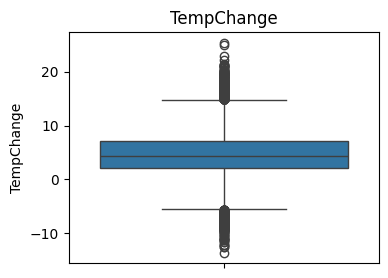

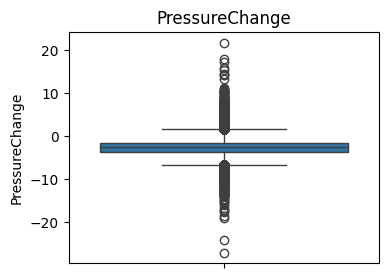

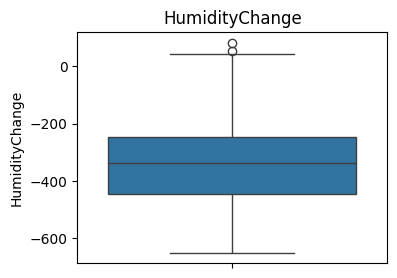

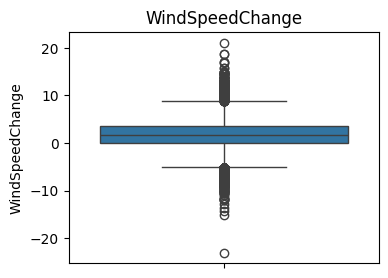

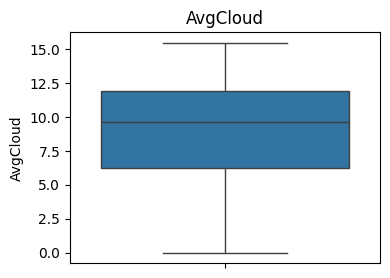

In [ ]:
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [52]:
# use cliping to get extreme values
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  df[col] = np.clip(df[col],lower,upper)

In [53]:
df.shape

(142193, 30)

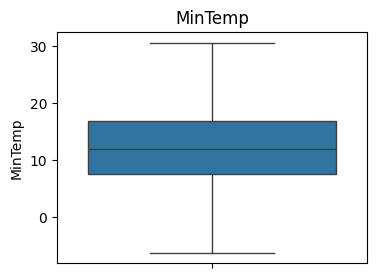

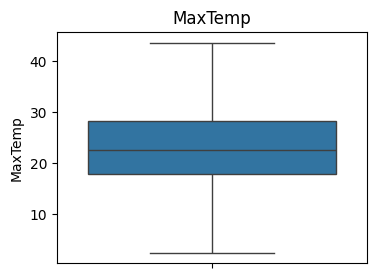

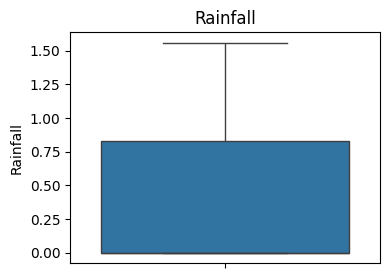

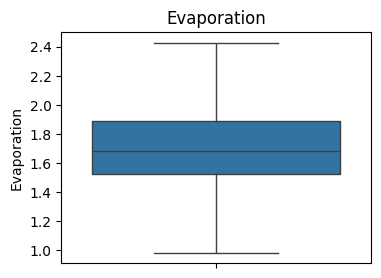

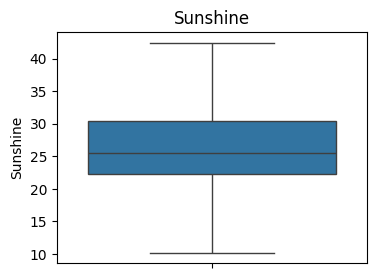

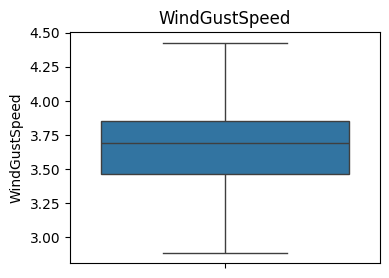

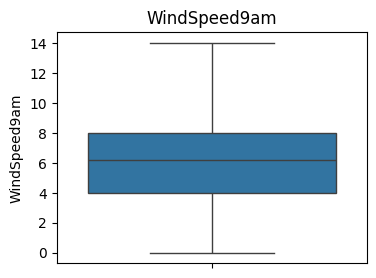

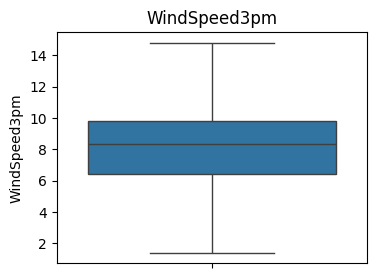

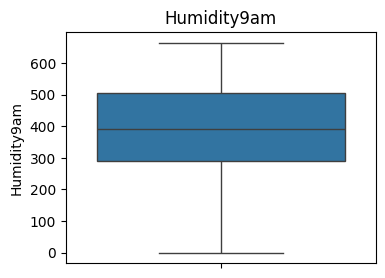

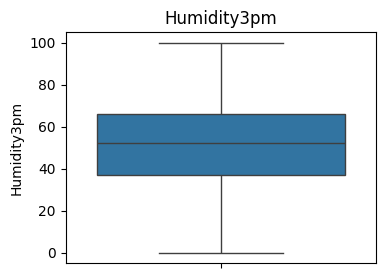

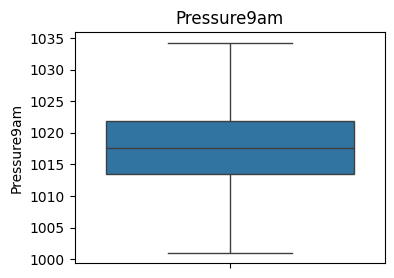

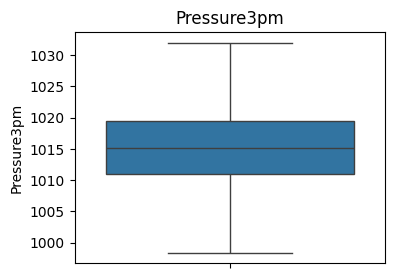

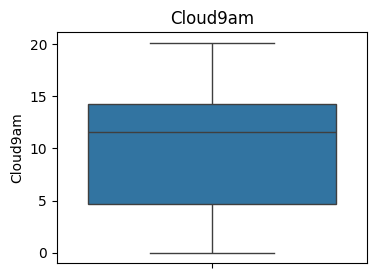

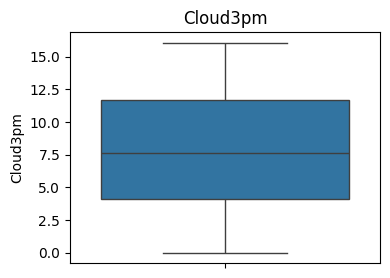

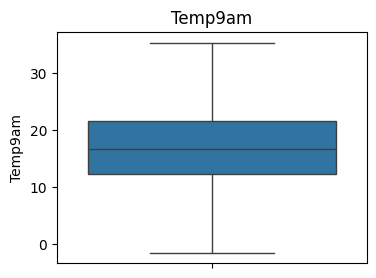

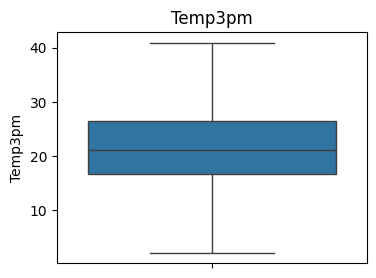

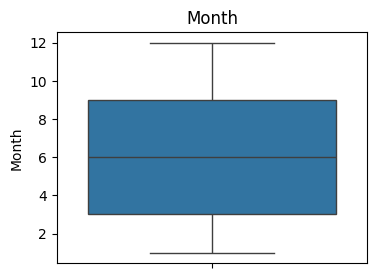

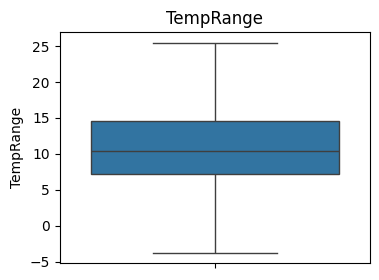

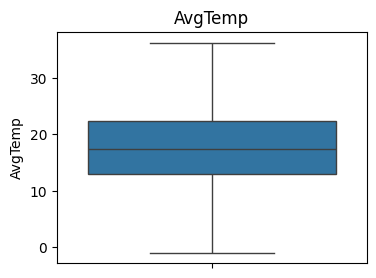

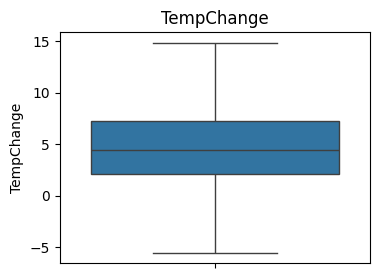

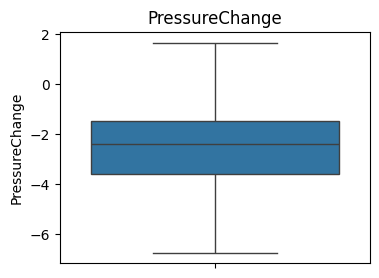

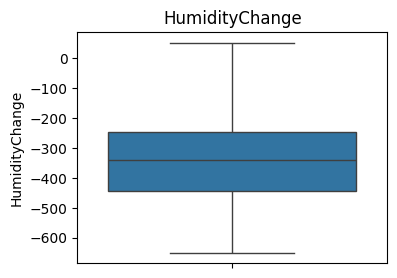

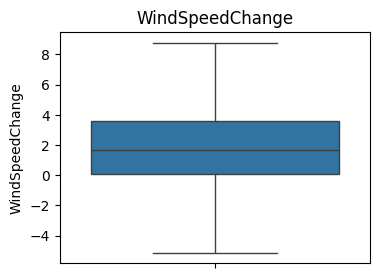

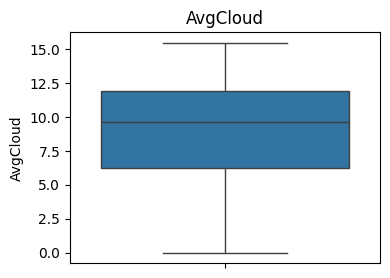

In [ ]:
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

# checking multicollinarity

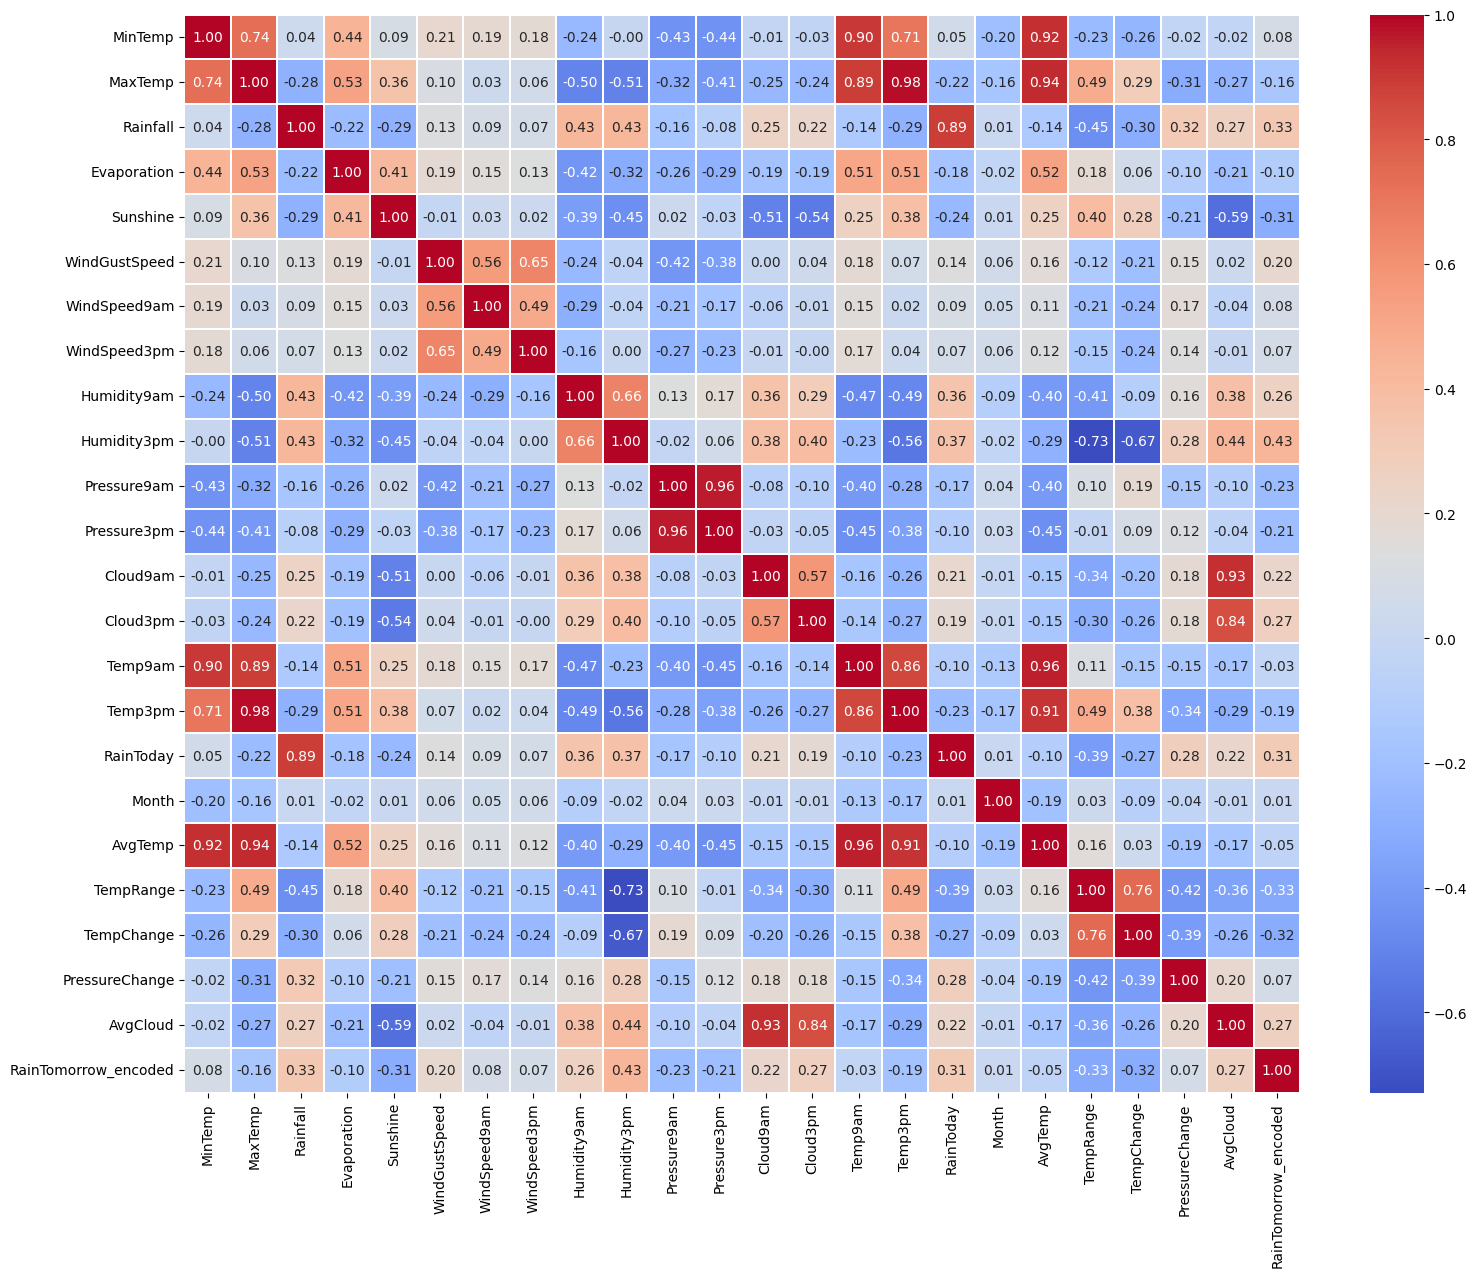

In [ ]:
plt.figure(figsize=(18,14))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.1)
plt.show('corration between variables')

In [54]:
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'Month', 'TempRange', 'AvgTemp', 'TempChange',
       'PressureChange', 'HumidityChange', 'WindSpeedChange', 'AvgCloud'],
      dtype='object')

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Feature"] = num_cols
vif["VIF"] = [variance_inflation_factor(df[num_cols].values, i) for i in range(len(num_cols))]

print(vif)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


            Feature           VIF
0           MinTemp  5.060662e+04
1           MaxTemp  1.210925e+05
2          Rainfall  2.314387e+00
3       Evaporation  3.659475e+01
4          Sunshine  1.756155e+01
5     WindGustSpeed  2.906931e+02
6      WindSpeed9am  6.645205e+02
7      WindSpeed3pm  1.053561e+03
8       Humidity9am  2.925338e+07
9       Humidity3pm  5.068483e+05
10      Pressure9am  5.312361e+06
11      Pressure3pm  5.287174e+06
12         Cloud9am           inf
13         Cloud3pm           inf
14          Temp9am  9.498596e+03
15          Temp3pm  1.488612e+04
16            Month  5.091801e+00
17        TempRange  7.570516e+03
18          AvgTemp  2.603983e+05
19       TempChange  1.031272e+03
20   PressureChange  5.329458e+01
21   HumidityChange  2.240799e+07
22  WindSpeedChange  1.638739e+02
23         AvgCloud           inf


In [56]:
high_vif = ['Humidity9am','Pressure3pm','MinTemp'
            ,'Temp9am','Cloud3pm','WindSpeed9am']
new_viff = num_cols.drop(high_vif)

In [57]:
new_viff

Index(['MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
       'WindSpeed3pm', 'Humidity3pm', 'Pressure9am', 'Cloud9am', 'Temp3pm',
       'Month', 'TempRange', 'AvgTemp', 'TempChange', 'PressureChange',
       'HumidityChange', 'WindSpeedChange', 'AvgCloud'],
      dtype='object')

In [58]:
vif_data = pd.DataFrame()
vif_data['Feature'] = new_viff
vif_data['VIF'] = [variance_inflation_factor(df[new_viff].values, i) for i in range(len(new_viff))]
print(vif_data.sort_values('VIF', ascending=False))

            Feature           VIF
0           MaxTemp  66295.413749
12          AvgTemp  38809.847852
11        TempRange   4087.308986
9           Temp3pm    534.777498
7       Pressure9am    329.307888
4     WindGustSpeed    290.220170
17         AvgCloud     42.791677
2       Evaporation     36.586305
6       Humidity3pm     35.943023
8          Cloud9am     29.806478
5      WindSpeed3pm     27.260886
15   HumidityChange     23.836689
13       TempChange     17.832976
3          Sunshine     17.559340
10            Month      5.091002
14   PressureChange      4.149705
16  WindSpeedChange      2.342579
1          Rainfall      2.312964


In [61]:
new_viff1 = new_viff.drop(['MaxTemp','Temp3pm','Pressure9am','WindGustSpeed'])

In [62]:
vif_data = pd.DataFrame()
vif_data['Feature'] = new_viff1
vif_data['VIF'] = [variance_inflation_factor(df[new_viff1].values, i) for i in range(len(new_viff1))]
print(vif_data.sort_values('VIF', ascending=False))

            Feature        VIF
13         AvgCloud  41.777245
1       Evaporation  33.119030
5          Cloud9am  29.728491
4       Humidity3pm  26.987485
11   HumidityChange  22.628386
7         TempRange  19.080851
2          Sunshine  16.020783
8           AvgTemp  14.034076
9        TempChange  13.064763
3      WindSpeed3pm  12.847402
6             Month   4.806323
10   PressureChange   4.073906
0          Rainfall   2.251511
12  WindSpeedChange   1.984726


In [66]:
new_df = new_viff1.drop(['Cloud9am','Humidity3pm','Evaporation','TempRange'])

In [67]:
vif_data = pd.DataFrame()
vif_data['Feature'] = new_df
vif_data['VIF'] = [variance_inflation_factor(df[new_df].values, i) for i in range(len(new_df))]
print(vif_data.sort_values('VIF', ascending=False))

           Feature        VIF
2     WindSpeed3pm  11.761701
1         Sunshine  11.478635
4          AvgTemp   9.953790
7   HumidityChange   9.078492
9         AvgCloud   6.934574
3            Month   4.437271
6   PressureChange   3.862422
5       TempChange   3.826863
0         Rainfall   2.199757
8  WindSpeedChange   1.861609


In [78]:
df_encoded=pd.DataFrame(df_encoded)

In [73]:
df_encoded.dtypes

,0
0,float64
1,float64
2,float64
3,float64
4,float64
...,...
89,float64
90,float64
91,float64
92,float64


In [76]:
df_encoded = df_encoded.columns.tolist()

In [86]:
df_encoded.head()

,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# scaling and spliting data

In [87]:
# Numerical features to keep from df (based on VIF analysis and 'RainToday')
# 'new_df' is a pandas Index object from the VIF analysis, so convert to list
features_from_df = new_df.tolist() + ['RainToday']

# Ensure df_encoded has the same index as df for correct concatenation
# This handles cases where df's index might have gaps after dropna
df_encoded = df_encoded.set_index(df.index)

# Create x by concatenating selected numerical features from df and the one-hot encoded features
# These features will not include 'RainTomorrow' or other target/dropped features by design
x = pd.concat([df[features_from_df], df_encoded], axis=1)

# Define y as the target variable
y = df['RainTomorrow']

In [88]:
x.head()

,Rainfall,Sunshine,WindSpeed3pm,Month,AvgTemp,TempChange,PressureChange,HumidityChange,WindSpeedChange,AvgCloud,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.938143,25.493352,9.776384,12.0,18.15,4.9,-0.6,-378.424625,1.466847,14.399031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000000,25.493352,9.220039,12.0,16.25,7.1,-2.8,-172.910257,6.566159,14.399031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000000,25.493352,10.315071,12.0,19.30,2.2,1.1,-129.646831,2.284369,9.828411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000000,25.493352,4.949878,12.0,18.60,8.4,-4.8,-188.547018,-0.587890,14.399031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,25.493352,8.643838,12.0,24.90,11.9,-4.8,-462.467996,4.623035,14.042927,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train, X_test ,Y_train ,Y_test = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y )

In [92]:
X_train.shape, X_test.shape

((113754, 105), (28439, 105))

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [94]:
type(X_train_scaled)

numpy.ndarray

In [95]:
X_train_scaled = pd.DataFrame(X_train_scaled)
X_test_scaled  = pd.DataFrame(X_test_scaled)

# Model Training

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score ,log_loss, f1_score, roc_auc_score,classification_report

In [97]:
from imblearn.over_sampling import SMOTE #smote techniqe to handle imbalanced dataset

smote = SMOTE(random_state=42)
X_retrain, y_retrain = smote.fit_resample(X_train_scaled, Y_train)

In [112]:
model = LogisticRegression(class_weight='balanced', random_state=42,max_iter=1000)
model.fit(X_retrain, y_retrain)
y_pred = model.predict(X_test_scaled)

In [113]:
y_prob = model.predict_proba(X_test_scaled)[:,1]


In [114]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Accuracy: 0.7550546784345441

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     22064
           1       0.47      0.76      0.58      6375

    accuracy                           0.76     28439
   macro avg       0.69      0.76      0.70     28439
weighted avg       0.82      0.76      0.77     28439



In [101]:
print("ROC-AUC:", roc_auc_score(Y_test, y_prob))


ROC-AUC: 0.8352479702540914


In [102]:
print("Log Loss:", log_loss(Y_test, y_prob))

Log Loss: 0.49655644570915275


# dumpping file

In [105]:
columns_for_inference = X_train.columns.tolist()

In [103]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [106]:
import pickle

# save model
pickle.dump(model, open('model.pkl', 'wb'))

# save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# save column names used during training
pickle.dump(columns_for_inference, open('columns.pkl', 'wb'))

In [107]:
import pickle

# save model
pickle.dump(model, open('model.pkl', 'wb'))

# save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# save column names used during training
pickle.dump(columns_for_inference, open('columns.pkl', 'wb'))

# save encoder
pickle.dump(encoder, open('encoder.pkl', 'wb'))

In [109]:
import joblib

In [116]:
joblib.dump(model, "model.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train_scaled.columns, "columns.pkl")

['columns.pkl']

In [119]:
# loading file

model = joblib.load("model.pkl")
encoder = joblib.load("encoder.pkl")
scaler = joblib.load("scaler.pkl")
train_columns = joblib.load("columns.pkl")